## 1. Import Libraries

In [53]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

## 2. Load Data

In [54]:
trades = pd.read_csv("historical_data.csv")
fear = pd.read_csv("fear_greed_index.csv")

In [55]:
print(trades.shape)
print(fear.shape)

(211224, 16)
(2644, 4)


In [56]:
print(trades.columns)
print(fear.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


## 3. Data Cleaning

### Trading Data

In [57]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [58]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

### Fear & Greed Data

In [59]:
fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [60]:
fear['date'] = pd.to_datetime(
    fear['date']
).dt.date

In [61]:
print(trades.isnull().sum())
print(fear.isnull().sum())

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
timestamp         0
value             0
classification    0
date              0
dtype: int64


## 4. Merge Both Datasets

In [62]:
print(trades.columns.tolist())
print(fear.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
['timestamp', 'value', 'classification', 'date']


In [63]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True,
    format='mixed'
)

trades['date'] = trades['Timestamp IST'].dt.date

print(trades[['Timestamp IST','date']].head())

        Timestamp IST        date
0 2024-12-02 22:50:00  2024-12-02
1 2024-12-02 22:50:00  2024-12-02
2 2024-12-02 22:50:00  2024-12-02
3 2024-12-02 22:50:00  2024-12-02
4 2024-12-02 22:50:00  2024-12-02


In [64]:
merged = trades.merge(
    fear,
    on='date',
    how='left'
)

In [65]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed


## 5. Basic Dataset Overview

In [66]:
print("Rows:", merged.shape[0])
print("Columns:", merged.shape[1])

merged.info()

Rows: 211224
Columns: 20
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null 

## 6. Sentiment Distribution

### Chart 1

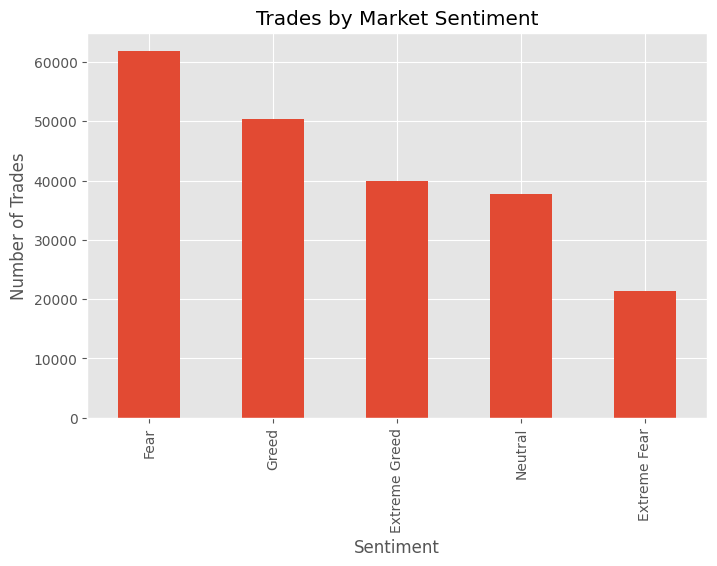

In [67]:
plt.figure(figsize=(8,5))

merged['classification'].value_counts().plot(
    kind='bar'
)

plt.title('Trades by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Trades')

plt.show()

## Insight

Most trades occurred during Fear and Greed periods. Extreme Fear had the lowest trading activity.

## 7. Average PnL by Sentiment

### Chart 2

In [68]:
avg_pnl = merged.groupby(
    'classification'
)['Closed PnL'].mean().sort_values()

print(avg_pnl)

classification
Neutral          34.307718
Extreme Fear     34.537862
Greed            42.743559
Fear             54.290400
Extreme Greed    67.892861
Name: Closed PnL, dtype: float64


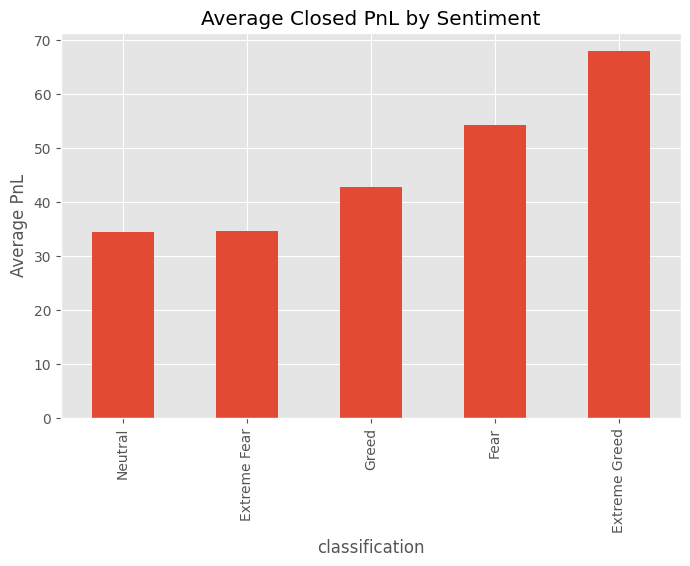

In [69]:
plt.figure(figsize=(8,5))

avg_pnl.plot(kind='bar')

plt.title('Average Closed PnL by Sentiment')
plt.ylabel('Average PnL')

plt.show()

## Insight

Traders generated the highest average profits during Extreme Greed periods and the lowest during Extreme Fear periods.

## 8. Total Profit by Sentiment

### Chart 3

In [70]:
total_pnl = merged.groupby(
    'classification'
)['Closed PnL'].sum()

print(total_pnl)

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64


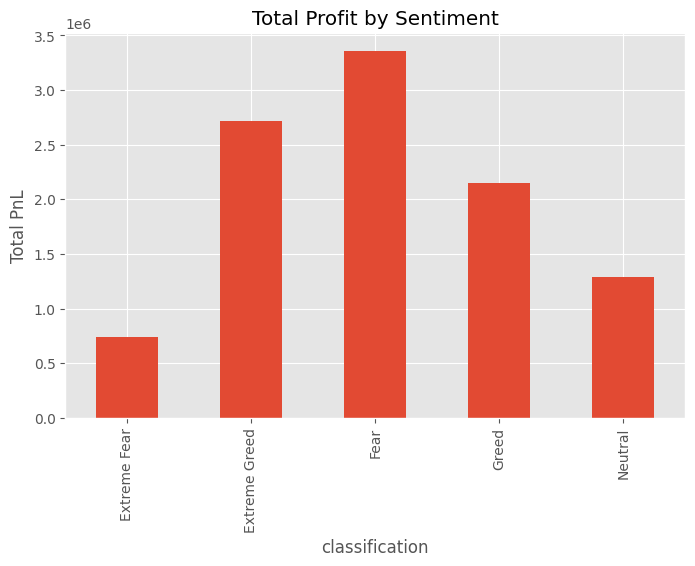

In [71]:
total_pnl.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Total Profit by Sentiment")
plt.ylabel("Total PnL")

plt.show()

## 9. Win Rate Analysis

In [72]:
merged['win'] = merged['Closed PnL'] > 0

In [73]:
win_rate = merged.groupby(
    'classification'
)['win'].mean()*100

print(win_rate)

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: win, dtype: float64


### Chart 4

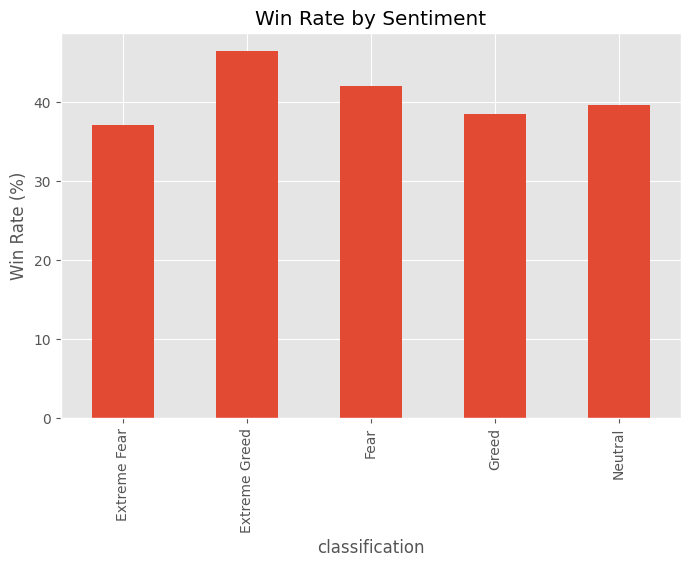

In [74]:
win_rate.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate (%)")

plt.show()

### Insight

Win rates improve significantly during Greed and Extreme Greed conditions.

## 10. Buy vs Sell Analysis

### Chart 5

In [75]:
side_analysis = pd.crosstab(
    merged['classification'],
    merged['Side']
)

print(side_analysis)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


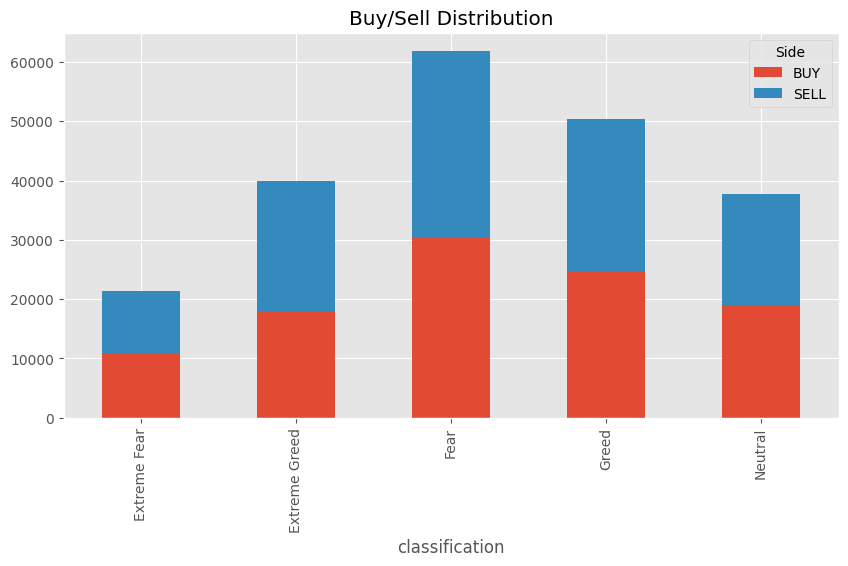

In [76]:
side_analysis.plot(
    kind='bar',
    stacked=True,
    figsize=(10,5)
)

plt.title("Buy/Sell Distribution")
plt.show()

### Insight

Trading behavior changes with market sentiment. Buy-side activity increases during Greed periods.

## 11. Long vs Short Analysis

### Chart 6

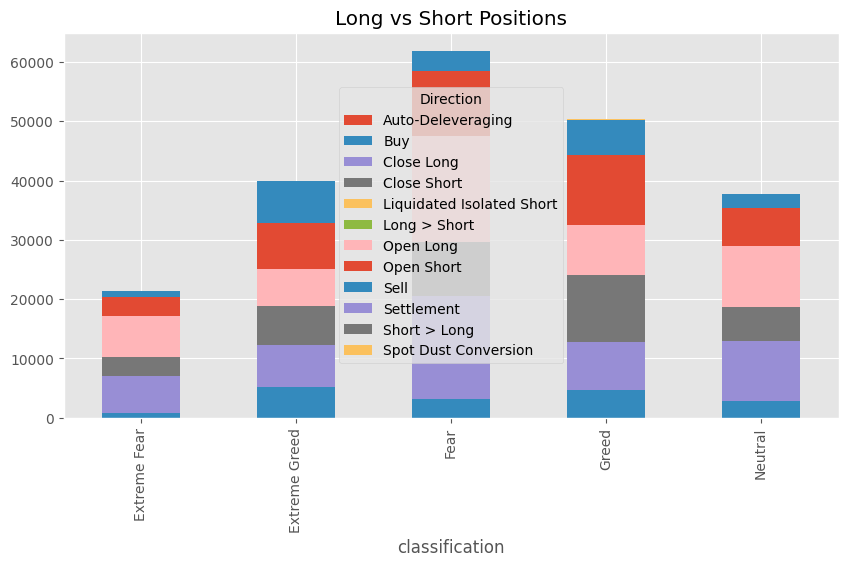

In [77]:
direction_analysis = pd.crosstab(
    merged['classification'],
    merged['Direction']
)

direction_analysis.plot(
    kind='bar',
    stacked=True,
    figsize=(10,5)
)

plt.title("Long vs Short Positions")
plt.show()

### Insight

Long positions dominate during Greed while Short positions become more common during Fear.

## 12. Top 10 Traders

In [78]:
top_traders = merged.groupby(
    'Account'
)['Closed PnL'].sum().sort_values(
    ascending=False
).head(10)

print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


### Chart 7

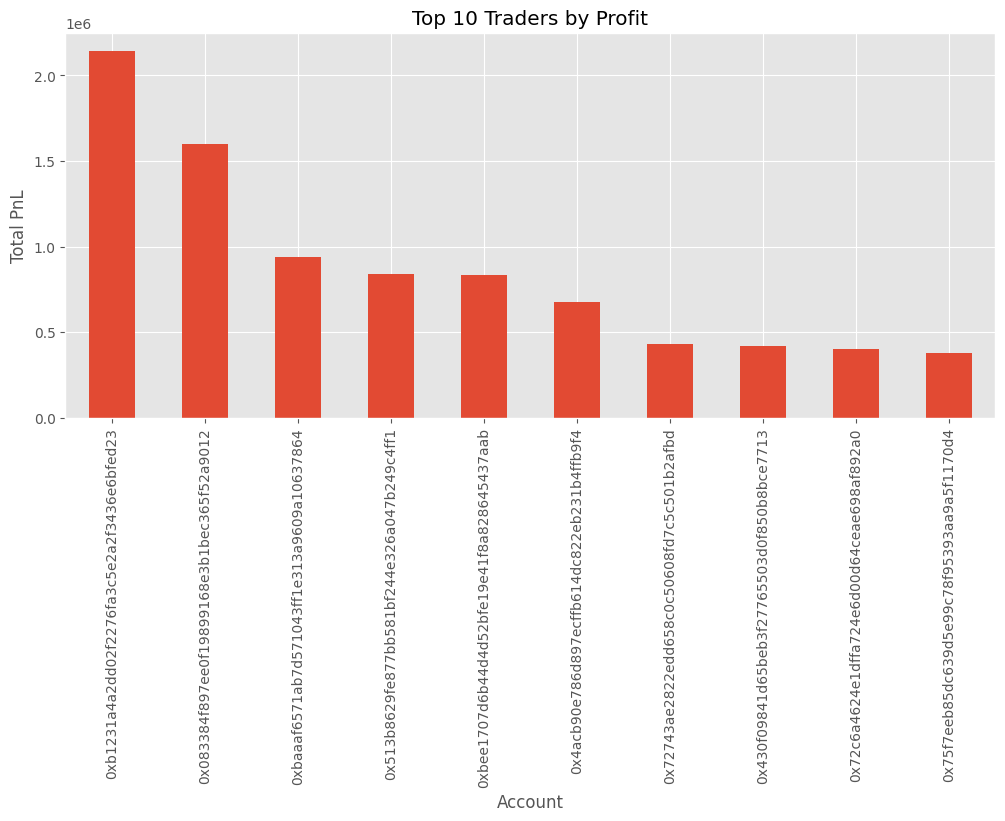

In [79]:
top_traders.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Top 10 Traders by Profit")
plt.ylabel("Total PnL")

plt.show()

## 13. Asset Analysis

In [80]:
coin_profit = merged.groupby(
    'Coin'
)['Closed PnL'].sum().sort_values(
    ascending=False
).head(10)

print(coin_profit)

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


### Chart 8

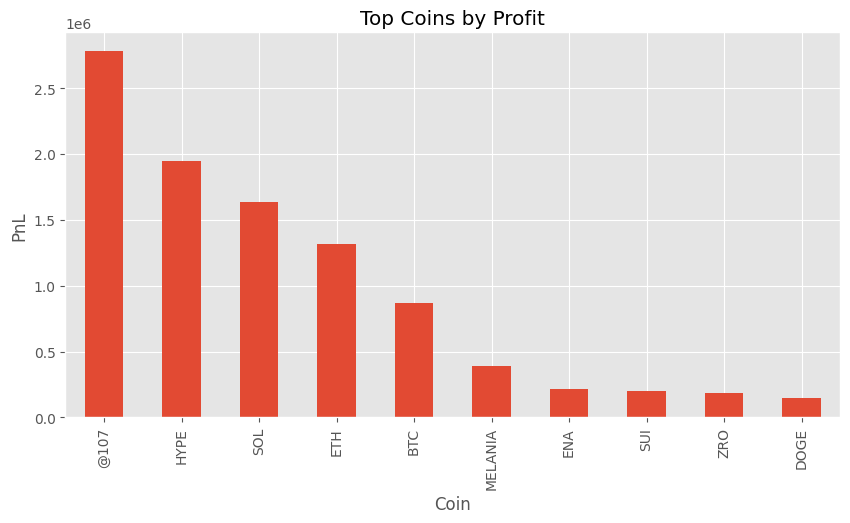

In [81]:
coin_profit.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Coins by Profit")
plt.ylabel("PnL")

plt.show()

## 14.PnL Distribution

### Chart 9

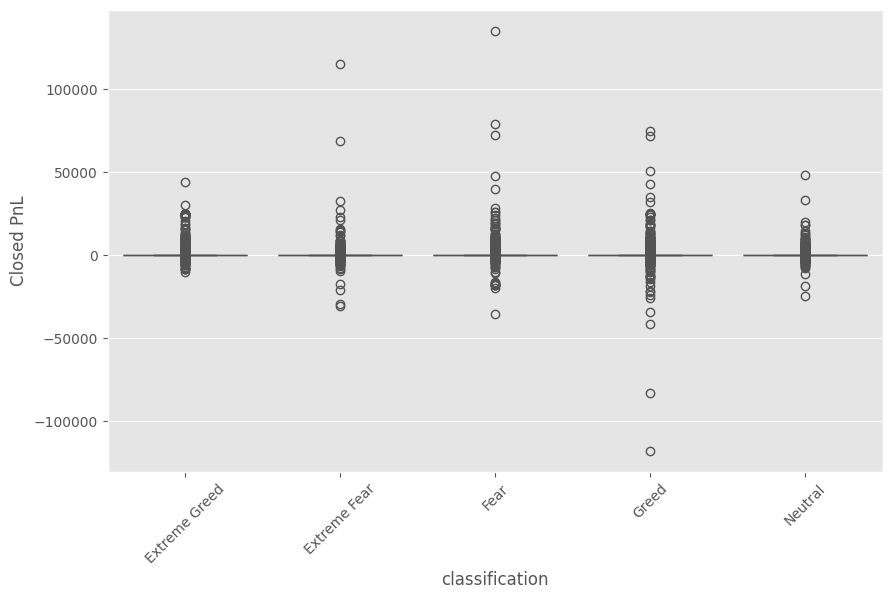

In [82]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.xticks(rotation=45)

plt.show()

### Insight

Extreme Greed periods show higher profit potential but also greater variability in outcomes.

## 15. Correlation Analysis

In [83]:
numeric_cols = [
    'Execution Price',
    'Size USD',
    'Fee',
    'Closed PnL'
]

corr = merged[numeric_cols].corr()

print(corr)

                 Execution Price  Size USD       Fee  Closed PnL
Execution Price         1.000000  0.189855  0.225265   -0.006505
Size USD                0.189855  1.000000  0.745939    0.123589
Fee                     0.225265  0.745939  1.000000    0.084020
Closed PnL             -0.006505  0.123589  0.084020    1.000000


### Heatmap

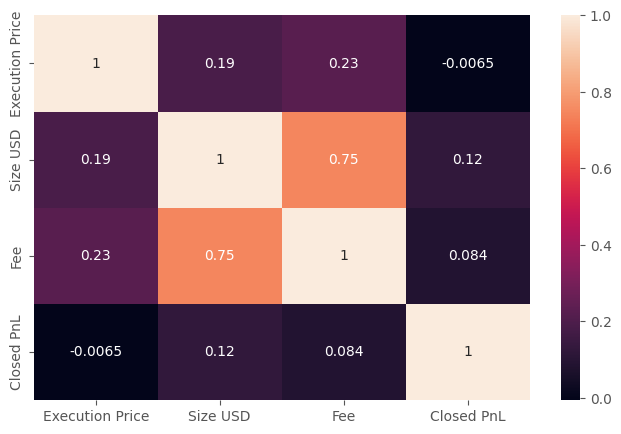

In [84]:
plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True
)

plt.show()

In [85]:
merged.shape
merged.head()
merged['classification'].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


## 16. Key Findings

1. Trader profitability increases during Greed and Extreme Greed periods.
2. Extreme Fear periods generate the lowest average returns.
3. Positive market sentiment is associated with higher win rates.
4. Long positions become more frequent during Greed conditions.
5. Market sentiment can be used as a useful supplementary trading signal.

## 17. Business Recommendations

1. Incorporate the Fear & Greed Index into trading strategies.
2. Reduce leverage and position sizes during Extreme Fear periods.
3. Increase risk exposure only when sentiment aligns with technical indicators.
4. Monitor sentiment shifts as an early warning signal.
5. Combine sentiment indicators with quantitative models for better decision-making.

## 18. Conclusion

This analysis explored the relationship between Bitcoin market sentiment and trader performance using Hyperliquid historical trading data and the Fear & Greed Index. Results indicate that trader profitability and win rates tend to improve during Greed and Extreme Greed periods, while Fear conditions are associated with weaker performance. These findings suggest that market sentiment can provide valuable context for risk management and trading decisions.